### Q2. Effect Of Feature Scaling on Optimisation [2 Marks]

```python
num_samples = 100
np.random.seed(42)

# Generate data with large feature scale
x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps
```

- **[1 marks]** Using the above dataset, implement full-batch gradient descent for linear regression on the dataset above without any feature scaling. Define the convergence criterion as reaching an epsilon-neighborhood of the empirical least squares minimizer θ*, with ε = 0.001 ( $\|\theta_t - \theta^*\| < \epsilon$ ). Determine the number of iterations required to satisfy this convergence criterion. Plot mse loss versus iterations plot.

- **[1 marks]** Apply z-score normalization to the feature: $x_{\text{scaled}} = \frac{x - \mu_x}{\sigma_x}$ Run full-batch gradient descent on the scaled dataset with the same convergence criterion $(\epsilon = 0.001)$. Determine the number of iterations required for convergence. Plot mse loss versus iterations plot.

In [20]:
import numpy as np 
import matplotlib.pyplot as plt

In [21]:
EPSILON = 0.01

#### some utilities function

In [22]:
def get_true_theta(x, y):
    # X = [x, 1]
    X = np.column_stack((x, np.ones_like(x)))
    #  theta = (X^T X)^(-1) X^T y
    theta_star = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta_star

In [23]:
def epsilon_dist(theta_t, theta_star):
    return np.linalg.norm(theta_t - theta_star)

In [24]:
def compute_loss_for_params(x, y, w, b):
    pred = w * x + b
    return np.mean((pred - y)**2)

#### core: gradient descent

In [25]:
def gradient_descent(x, y, lr=0.01, max_epochs= 100, batch_size=10):
    np.random.seed(445)

    n = len(y)
    w = np.random.randn()
    b = 0.0
    theta_star = get_true_theta(x, y)
    trace_updates = [(w, b)]
    epoch_trace = []
    loss_epoch = []
    steps = 0
    converged = False
    steps_to_converge = None
    for epoch in range(max_epochs):
        indices = np.arange(n)
        # np.random.shuffle(indices)
        
        for start in range(0, n, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]
            
            y_pred = w * x_batch + b
            error = y_pred - y_batch
            
            dw = (2/batch_size) * np.dot(error, x_batch)
            db = (2/batch_size) * np.sum(error)
        
            w = w - lr * dw
            b = b - lr * db
            steps += 1
            trace_updates.append((w, b))
            theta_t = np.array([w, b])
            
            eps_dist = epsilon_dist(theta_t, theta_star)
            if eps_dist < EPSILON:
                converged = True
                steps_to_converge = steps
                break
            
        epoch_trace.append((w, b))
        loss_epoch.append(compute_loss_for_params(x, y, w, b))
        
        if converged:
            break
            
    return {
        'trace_updates': np.array(trace_updates),   # shape (steps+1, 2)
        'epoch_trace': np.array(epoch_trace),       # shape (epochs_done, 2)
        'loss_epoch': np.array(loss_epoch),         # shape (epochs_done,)
        'steps_to_converge': steps_to_converge,
        'converged': converged
    }

In [26]:
num_samples = 100
np.random.seed(42)

# Generate data with large feature scale
x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps

#### without normalization

/tmp/ipykernel_37356/3790414302.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((pred - y)**2)
/home/balbir/pjct/py-pjct/es335/es335Env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_37356/3429265045.py:27: RuntimeWarning: overflow encountered in dot
  dw = (2/batch_size) * np.dot(error, x_batch)
/home/balbir/pjct/py-pjct/es335/es335Env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_37356/3429265045.py:30: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * dw
/tmp/ipykernel_37356/3429265045.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - lr * db


False
None


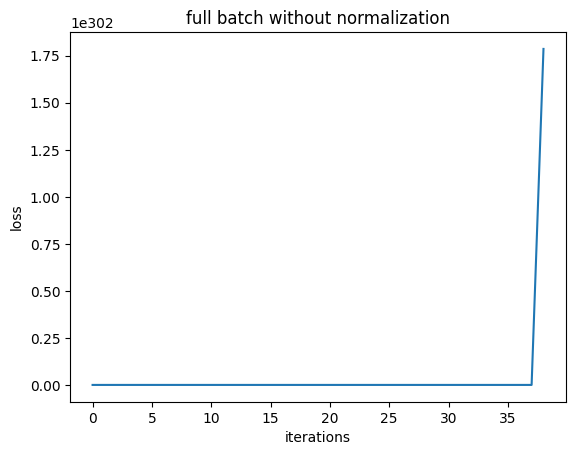

In [27]:
res = gradient_descent(x, y, lr=0.01, max_epochs=5000, batch_size=len(y))
print(res['converged'])
print(res['steps_to_converge'])
plt.plot(res['loss_epoch'])
plt.title('full batch without normalization')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()


#### with normalization

In [28]:
# z-score normalization
x_scaled = (x - np.mean(x)) / np.std(x)

True
596


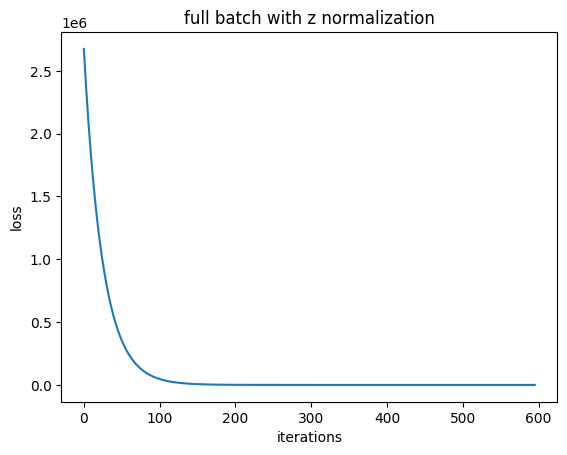

In [29]:
res = gradient_descent(x_scaled, y, lr=0.01, max_epochs=1000, batch_size=len(y))
print(res['converged'])
print(res['steps_to_converge'])
plt.plot(res['loss_epoch'])
plt.title('full batch with z normalization')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()

### Subjective answers
Case 1: Without normalization

In this case, the model did not converge to the true theta. The loss is still high even after 5000 iterations.

Case 2: With normalization

In this case, the model converged to the true theta. The loss is much lower than the case without normalization.

This concludes that normalization helps in convergence of the model.